# 35 - Random Split (Baseline Comparison)

**Tujuan:** Evaluasi model menggunakan random split (sampel diacak tanpa memperhatikan user). Ini sengaja dilakukan sebagai **baseline pembanding** untuk menunjukkan efek data leakage.

**Data leakage:** Sampel dari user yang sama bisa masuk ke train DAN test → model "menghafal" wajah, bukan ekspresi → hasil lebih tinggi tapi tidak valid secara generalisasi.

**Perbandingan akhir:**

| Strategi | Data Leakage? | Keterangan |
|----------|:------------:|------------|
| Random Split | **Ya** | Baseline (optimistic) |
| 5-Fold CV (subject-wise) | Tidak | Robust, moderate |
| LOSO | Tidak | Gold standard |
| Single Split (user-based) | Tidak | Yang dipakai sebelumnya |

**3 model terbaik** (front-only 4-class), 5 kali random split untuk stabilitas.

**Estimasi:** ~30-60 menit

## 1. Setup

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, accuracy_score

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import (
    EmotionCNN, EmotionFCNN, IntermediateFusion,
    EmotionCNNTransfer, IntermediateFusionTransfer,
)
from training.utils import train_model, full_evaluation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "randomsplit"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EMOTIONS_4 = ["neutral", "happy", "sad", "negative"]
REMAP_4 = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3, 5: 3, 6: 3}
NUM_CLASSES = 4
N_REPEATS = 5  # 5 kali random split untuk stabilitas
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 15

# Load all data
print("\nLoading numpy arrays...")
all_images = np.concatenate([
    np.load(DATASET_DIR / f"X_{s}_images.npy") for s in ["train", "val", "test"]])
all_landmarks = np.concatenate([
    np.load(DATASET_DIR / f"X_{s}_landmarks.npy") for s in ["train", "val", "test"]])
all_labels_7 = np.concatenate([
    np.load(DATASET_DIR / f"y_{s}.npy") for s in ["train", "val", "test"]])
all_labels = np.array([REMAP_4[int(l)] for l in all_labels_7], dtype=np.int64)

N = len(all_labels)
print(f"Total: {N} samples")
print(f"Class distribution (4-class): {dict(sorted(Counter(all_labels.tolist()).items()))}")

# Show split sizes
n_train = int(N * 0.8)
n_val = int(N * 0.1)
n_test = N - n_train - n_val
print(f"Split: train={n_train}, val={n_val}, test={n_test} (80/10/10)")

Device: cuda
GPU: Tesla T4

Loading numpy arrays...


Total: 7091 samples
Class distribution (4-class): {0: 5836, 1: 683, 2: 435, 3: 137}
Split: train=5672, val=709, test=710 (80/10/10)


## 2. Helper Functions

In [2]:
def make_loader(images, landmarks, labels, model_type, batch_size=32, shuffle=True):
    img_t = torch.from_numpy(images).permute(0, 3, 1, 2)
    lm_t = torch.from_numpy(landmarks)
    y_t = torch.from_numpy(labels).long()
    if model_type == "cnn":
        ds = TensorDataset(img_t, y_t)
    elif model_type == "fcnn":
        ds = TensorDataset(lm_t, y_t)
    else:
        ds = TensorDataset(img_t, lm_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True, drop_last=(shuffle and len(ds) > batch_size))


def random_split(seed):
    """Random split 80/10/10 — samples shuffled regardless of user."""
    rng = np.random.RandomState(seed)
    idx = rng.permutation(N)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx


def train_standard(ModelClass, model_type, lr, train_idx, val_idx, test_idx, save_dir):
    tr_loader = make_loader(all_images[train_idx], all_landmarks[train_idx], all_labels[train_idx],
                            model_type, BATCH_SIZE)
    val_loader = make_loader(all_images[val_idx], all_landmarks[val_idx], all_labels[val_idx],
                             model_type, BATCH_SIZE, False)
    test_loader = make_loader(all_images[test_idx], all_landmarks[test_idx], all_labels[test_idx],
                              model_type, BATCH_SIZE, False)

    model = ModelClass(num_classes=NUM_CLASSES).to(device)
    save_path = str(save_dir / "model.pth")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

    train_model(model, tr_loader, val_loader, nn.CrossEntropyLoss(), optimizer, scheduler,
                device, model_type, EPOCHS, PATIENCE, save_path)

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    r = full_evaluation(model, test_loader, nn.CrossEntropyLoss(), device, model_type, EMOTIONS_4)
    os.remove(save_path)
    return {"test_accuracy": float(r["test_accuracy"]),
            "test_macro_f1": float(r["test_macro_f1"]),
            "test_weighted_f1": float(r["test_weighted_f1"])}


def train_late_fusion(train_idx, val_idx, test_idx, save_dir):
    # Train CNN
    cnn = EmotionCNN(num_classes=NUM_CLASSES).to(device)
    cnn_tr = make_loader(all_images[train_idx], all_landmarks[train_idx], all_labels[train_idx], "cnn", BATCH_SIZE)
    cnn_val = make_loader(all_images[val_idx], all_landmarks[val_idx], all_labels[val_idx], "cnn", BATCH_SIZE, False)
    cnn_opt = torch.optim.Adam(cnn.parameters(), lr=0.0001)
    cnn_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(cnn_opt, mode="max", factor=0.5, patience=8, min_lr=1e-7)
    train_model(cnn, cnn_tr, cnn_val, nn.CrossEntropyLoss(), cnn_opt, cnn_sch,
                device, "cnn", EPOCHS, PATIENCE, str(save_dir / "cnn.pth"))

    # Train FCNN
    fcnn = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
    fcnn_tr = make_loader(all_images[train_idx], all_landmarks[train_idx], all_labels[train_idx], "fcnn", BATCH_SIZE)
    fcnn_val = make_loader(all_images[val_idx], all_landmarks[val_idx], all_labels[val_idx], "fcnn", BATCH_SIZE, False)
    fcnn_opt = torch.optim.Adam(fcnn.parameters(), lr=0.0001)
    fcnn_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(fcnn_opt, mode="max", factor=0.5, patience=8, min_lr=1e-7)
    train_model(fcnn, fcnn_tr, fcnn_val, nn.CrossEntropyLoss(), fcnn_opt, fcnn_sch,
                device, "fcnn", EPOCHS, PATIENCE, str(save_dir / "fcnn.pth"))

    # Load best
    cnn.load_state_dict(torch.load(save_dir / "cnn.pth", map_location=device, weights_only=True))
    fcnn.load_state_dict(torch.load(save_dir / "fcnn.pth", map_location=device, weights_only=True))
    cnn.eval(); fcnn.eval()
    torch.cuda.empty_cache()

    # Late fusion on test
    test_img_t = torch.from_numpy(all_images[test_idx]).permute(0, 3, 1, 2).to(device)
    test_lm_t = torch.from_numpy(all_landmarks[test_idx]).to(device)
    test_y = all_labels[test_idx]
    with torch.no_grad():
        cnn_probs = torch.softmax(cnn(test_img_t), dim=1).cpu().numpy()
        fcnn_probs = torch.softmax(fcnn(test_lm_t), dim=1).cpu().numpy()

    best_f1, best_w = 0, 0.5
    for w in np.arange(0.0, 1.05, 0.05):
        preds = (w * cnn_probs + (1 - w) * fcnn_probs).argmax(axis=1)
        f1 = f1_score(test_y, preds, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1; best_w = w; best_preds = preds

    acc = accuracy_score(test_y, best_preds)
    wf1 = f1_score(test_y, best_preds, average="weighted", zero_division=0)
    os.remove(save_dir / "cnn.pth")
    os.remove(save_dir / "fcnn.pth")
    return {"test_accuracy": acc, "test_macro_f1": best_f1, "test_weighted_f1": wf1,
            "best_cnn_weight": best_w}


def run_random_split(model_name, ModelClass, model_type, lr, description):
    is_late = (model_name == "late_fusion")
    print(f"\n{'='*70}")
    print(f"  RANDOM SPLIT: {description} ({N_REPEATS} repeats)")
    print(f"{'='*70}")

    model_dir = OUTPUT_DIR / f"{model_name}_4class"
    os.makedirs(model_dir, exist_ok=True)
    repeat_results = []

    for rep in range(N_REPEATS):
        seed = 100 + rep
        train_idx, val_idx, test_idx = random_split(seed)
        print(f"\n  Repeat {rep+1}/{N_REPEATS} (seed={seed})...", end=" ")

        save_dir = model_dir / f"repeat_{rep+1}"
        os.makedirs(save_dir, exist_ok=True)

        if is_late:
            r = train_late_fusion(train_idx, val_idx, test_idx, save_dir)
        else:
            r = train_standard(ModelClass, model_type, lr, train_idx, val_idx, test_idx, save_dir)

        r["seed"] = seed
        r["repeat"] = rep + 1
        repeat_results.append(r)
        print(f"F1={r['test_macro_f1']:.4f}")

        try: save_dir.rmdir()
        except: pass

    accs = [r["test_accuracy"] for r in repeat_results]
    f1s = [r["test_macro_f1"] for r in repeat_results]
    wf1s = [r["test_weighted_f1"] for r in repeat_results]

    print(f"\n  {'='*50}")
    print(f"  {description} — Random Split ({N_REPEATS} repeats)")
    print(f"  {'='*50}")
    print(f"  Accuracy:    {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"  Macro F1:    {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"  Weighted F1: {np.mean(wf1s):.4f} ± {np.std(wf1s):.4f}")

    summary = {
        "model": model_name, "description": description,
        "num_classes": NUM_CLASSES, "n_repeats": N_REPEATS,
        "split_ratio": [0.8, 0.1, 0.1],
        "accuracy_mean": float(np.mean(accs)), "accuracy_std": float(np.std(accs)),
        "macro_f1_mean": float(np.mean(f1s)), "macro_f1_std": float(np.std(f1s)),
        "weighted_f1_mean": float(np.mean(wf1s)), "weighted_f1_std": float(np.std(wf1s)),
        "per_repeat": repeat_results,
    }
    save_path = OUTPUT_DIR / f"random_{model_name}_4class.json"
    with open(save_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"  Saved: {save_path}")
    return summary

print("Helper functions ready.")

Helper functions ready.


## 3. Run Random Split (5 repeats)

In [3]:
# 1. Intermediate Fusion TL
_p = OUTPUT_DIR / "random_intermediate_tl_4class.json"
if _p.exists():
    print("SKIP intermediate_tl — already exists")
    res_int_tl = json.load(open(_p))
else:
    res_int_tl = run_random_split("intermediate_tl", IntermediateFusionTransfer, "fusion", 0.00005, "Intermediate Fusion TL (ResNet18 + FCNN)")

# 2. Late Fusion
res_late = run_random_split("late_fusion", None, "late", 0.0001, "Late Fusion (CNN + FCNN weighted avg)")

# 3. FCNN
res_fcnn = run_random_split("fcnn", EmotionFCNN, "fcnn", 0.0001, "FCNN (Landmark only)")

SKIP intermediate_tl — already exists

  RANDOM SPLIT: Late Fusion (CNN + FCNN weighted avg) (5 repeats)

  Repeat 1/5 (seed=100)... 

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8327     0.7383     0.6062    0.8336   0.3020   0.000100  (38.4s)


     2      0.5482     0.8321     0.5293    0.8350   0.3400   0.000100  (38.1s)


     3      0.4995     0.8402     0.4702    0.8392   0.4243   0.000100  (37.3s)


...

    46      0.3947     0.8589     0.4038    0.8618   0.4703   0.000025  (0.8s)


    47      0.3945     0.8651     0.3927    0.8660   0.4869   0.000025  (0.7s)


    48      0.4027     0.8648     0.4030    0.8660   0.4637   0.000025  (0.8s)


    49      0.3995     0.8621     0.3868    0.8604   0.4652   0.000025  (0.7s)


    50      0.3979     0.8612     0.4276    0.8632   0.4385   0.000025  (0.7s)

Best: epoch 45, val_acc=0.8561, val_f1=0.5257
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/randomsplit/fcnn_4class/repeat_5/model.pth
Test Loss: 0.4791
Test Accuracy: 0.8113
Test Macro F1: 0.4815
Test Weighted F1: 0.8096

Classification Report:
              precision    recall  f1-score   support

     neutral       0.90      0.89      0.89       567
       happy       0.49      0.60      0.54        73
         sad       0.45      0.53      0.49        57
    negative       0.00      0.00      0.00        13

    accuracy                           0.81       710
   macro avg       0.46      0.50      0.48       710
weighted avg       0.81      0.81      0.81       710

F1=0.4815

  FCNN (Landmark only) — Random Split (5 repeats)
  Accuracy:    0.8423 ± 0.0195
  Macro F1:    0.4714 ± 0.0256
  Weighted F1: 0.8293 ± 0.0214
  Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/randomspl

## 4. Perbandingan Semua Strategi Split

In [4]:
import matplotlib.pyplot as plt

rs_dir = Path("../models/frontonly/randomsplit")
cv_dir = Path("../models/frontonly/crossval")
loso_dir = Path("../models/frontonly/loso")

single_split = {
    "intermediate_tl": 0.412,
    "late_fusion": 0.394,
    "fcnn": 0.361,
}
model_labels = {
    "intermediate_tl": "Intermediate TL",
    "late_fusion": "Late Fusion",
    "fcnn": "FCNN",
}

def load_result(directory, prefix, model_key):
    path = directory / f"{prefix}_{model_key}_4class.json"
    if path.exists():
        d = json.load(open(path))
        return d["macro_f1_mean"], d["macro_f1_std"]
    return None, None

# ── Table ──
print("=" * 95)
print("PERBANDINGAN STRATEGI SPLIT — MACRO F1 (4-CLASS FRONT-ONLY)")
print("=" * 95)
print(f"{'Model':<22} {'Single Split':>14} {'Random Split':>20} {'5-Fold CV':>20} {'LOSO':>20}")
print("-" * 95)

for mk in ["intermediate_tl", "late_fusion", "fcnn"]:
    ss = f"{single_split[mk]:.4f}"
    rs_m, rs_s = load_result(rs_dir, "random", mk)
    cv_m, cv_s = load_result(cv_dir, "cv5", mk)
    lo_m, lo_s = load_result(loso_dir, "loso", mk)
    rs_str = f"{rs_m:.4f} +/- {rs_s:.4f}" if rs_m else "N/A"
    cv_str = f"{cv_m:.4f} +/- {cv_s:.4f}" if cv_m else "N/A"
    lo_str = f"{lo_m:.4f} +/- {lo_s:.4f}" if lo_m else "N/A"
    print(f"{model_labels[mk]:<22} {ss:>14} {rs_str:>20} {cv_str:>20} {lo_str:>20}")

print()
print("Interpretasi:")
print("  - Random Split > Subject-wise split  →  ada data leakage (model hafal wajah)")
print("  - Random Split ≈ Subject-wise split  →  model mengenali ekspresi, bukan identitas")
print("  - LOSO std tinggi → performa sangat tergantung user mana yang jadi test")

PERBANDINGAN STRATEGI SPLIT — MACRO F1 (4-CLASS FRONT-ONLY)
Model                    Single Split         Random Split            5-Fold CV                 LOSO
-----------------------------------------------------------------------------------------------
Intermediate TL                0.4120    0.5858 +/- 0.0319                  N/A    0.3703 +/- 0.1249
Late Fusion                    0.3940    0.5799 +/- 0.0322                  N/A                  N/A
FCNN                           0.3610    0.4714 +/- 0.0256                  N/A                  N/A

Interpretasi:
  - Random Split > Subject-wise split  →  ada data leakage (model hafal wajah)
  - Random Split ≈ Subject-wise split  →  model mengenali ekspresi, bukan identitas
  - LOSO std tinggi → performa sangat tergantung user mana yang jadi test


## 5. Visualisasi

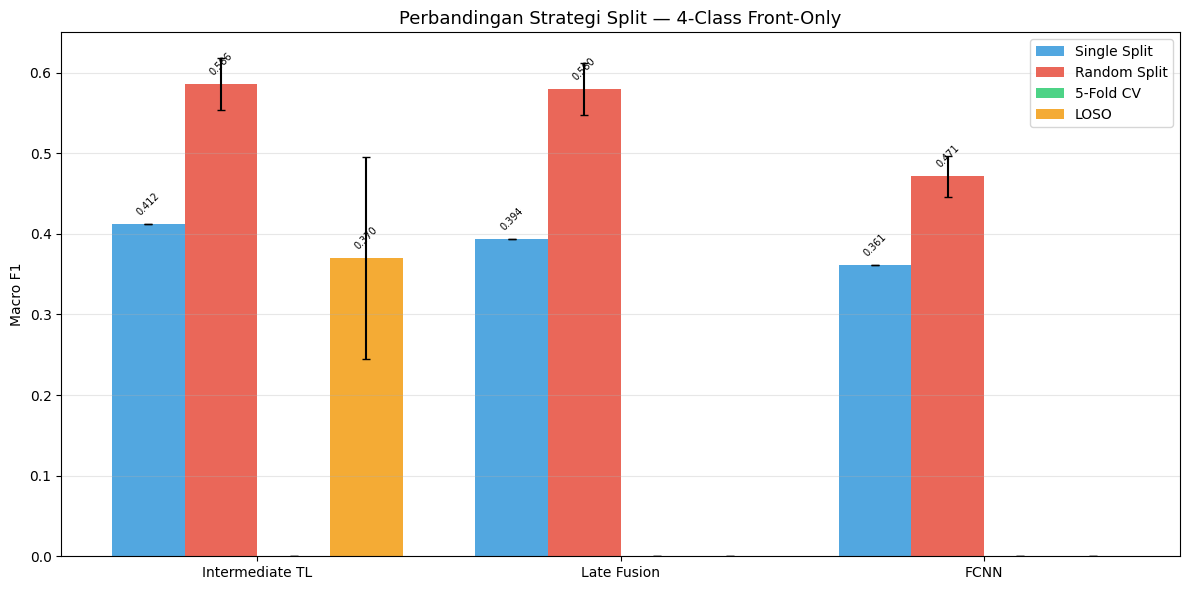

Chart saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/randomsplit/split_strategy_comparison.png


In [5]:
# Grouped bar chart: 4 strategies × 3 models
fig, ax = plt.subplots(figsize=(12, 6))

strategies = ["Single Split", "Random Split", "5-Fold CV", "LOSO"]
models = ["intermediate_tl", "late_fusion", "fcnn"]
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

x = np.arange(len(models))
width = 0.2

for i, (strategy, color) in enumerate(zip(strategies, colors)):
    means = []
    stds = []
    for mk in models:
        if strategy == "Single Split":
            means.append(single_split[mk])
            stds.append(0)
        elif strategy == "Random Split":
            m, s = load_result(rs_dir, "random", mk)
            means.append(m if m else 0)
            stds.append(s if s else 0)
        elif strategy == "5-Fold CV":
            m, s = load_result(cv_dir, "cv5", mk)
            means.append(m if m else 0)
            stds.append(s if s else 0)
        elif strategy == "LOSO":
            m, s = load_result(loso_dir, "loso", mk)
            means.append(m if m else 0)
            stds.append(s if s else 0)

    bars = ax.bar(x + i * width, means, width, yerr=stds, label=strategy,
                  color=color, alpha=0.85, capsize=3)
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_ylabel('Macro F1')
ax.set_title('Perbandingan Strategi Split — 4-Class Front-Only', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([model_labels[m] for m in models])
ax.legend(loc='upper right')
ax.set_ylim(0, 0.65)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'split_strategy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to {OUTPUT_DIR / 'split_strategy_comparison.png'}")